In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from src.simulation.synthetic_worlds.realistic_world import simulate_realistic_world
from src.simulation.train_lr_sim import train_logistic_regression
from src.simulation.train_mlp_sim import train_mlp_model, MLP

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from graphviz import Digraph


SEED = 42
np.random.seed(SEED)


In [34]:
df = simulate_realistic_world(n_samples=10000, seed=SEED)
df.head()


,race,gender,age,ses,bmi,glucose,hba1c,diabetes_true,diabetes_label
0,0,0,70.169189,0.381160,26.863763,94.690558,5.327640,0,0
1,2,1,49.973046,-0.780090,29.727480,90.798235,5.661694,1,1
2,1,1,40.183974,-0.318449,27.164268,93.959623,5.311289,1,1
3,0,1,51.476224,0.575729,26.682901,90.670604,5.680034,0,0
4,0,0,43.393592,1.191135,28.593290,80.244141,5.476292,0,0


In [35]:
from graphviz import Digraph

def exact_simulation_dag():
    dot = Digraph("Exact_DAG", format="png")

    # Nodes
    dot.node("Race")
    dot.node("Gender")
    dot.node("Age")
    dot.node("SES")
    dot.node("BMI")
    dot.node("Glucose")
    dot.node("HbA1c")
    dot.node("Risk")
    dot.node("Diabetes_True", "Diabetes (True)")
    dot.node("Diabetes_Label", "Diabetes (Observed Label)")

    # Structural edges
    dot.edge("Race", "SES")
    dot.edge("SES", "BMI")
    dot.edge("Gender", "BMI")

    dot.edge("BMI", "Glucose")
    dot.edge("BMI", "HbA1c")

    dot.edge("BMI", "Risk")
    dot.edge("Glucose", "Risk")
    dot.edge("HbA1c", "Risk")

    dot.edge("Risk", "Diabetes_True")

    # Measurement / label bias
    dot.edge("Diabetes_True", "Diabetes_Label")
    dot.edge("Race", "Diabetes_Label")
    dot.edge("Gender", "Diabetes_Label")

    # Age is isolated (intentional)
    return dot


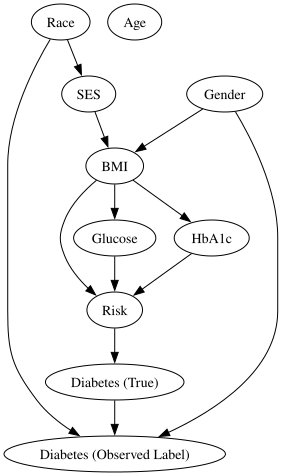

In [36]:
exact_simulation_dag()


In [37]:
X = df[["age", "ses", "bmi", "glucose", "hba1c"]]
# physiological, socioecnomic variables, no sensitive features, proxies allowed.
y = df["diabetes_true"]
# unbiased physiological measurements, no access bias


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
A = df[["race", "gender"]]
# not used by model

A_test = A.loc[X_test.index]
#fairness metrics are computed on the same samples





In [38]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)



In [39]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])


LR Accuracy: 0.658


In [40]:
# Logistic Regression outputs
lr_pred  = lr_results["y_pred"]
lr_proba = lr_results["y_proba"]

In [41]:
nn_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=X_train_s.shape[1]
)

print("NN Accuracy:", nn_results["accuracy"])

NN Accuracy: 0.6475


In [42]:


# Neural Network outputs
nn_pred  = nn_results["y_pred"]
nn_proba = nn_results["y_proba"]


In [43]:
def compute_group_rates(y_true, y_pred, group, group_name="group"):
    """
    Returns a DataFrame with TPR, FNR, FPR, TNR per group.
    """
    rows = []

    for g in sorted(np.unique(group)):
        idx = group == g

        tp = ((y_pred[idx] == 1) & (y_true[idx] == 1)).sum()
        fn = ((y_pred[idx] == 0) & (y_true[idx] == 1)).sum()
        fp = ((y_pred[idx] == 1) & (y_true[idx] == 0)).sum()
        tn = ((y_pred[idx] == 0) & (y_true[idx] == 0)).sum()

        tpr = tp / (tp + fn + 1e-9)  # sensitivity
        fnr = fn / (tp + fn + 1e-9)  # miss rate
        fpr = fp / (fp + tn + 1e-9)  # false alarm
        tnr = tn / (fp + tn + 1e-9)  # specificity

        rows.append({
            group_name: g,
            "TPR": tpr,
            "FNR": fnr,
            "FPR": fpr,
            "TNR": tnr
        })

    return pd.DataFrame(rows)

In [44]:
def compute_rate_gaps(rate_df):
    """
    Takes output of compute_group_rates
    and returns max–min gaps for each rate.
    """
    gaps = {}
    for col in ["TPR", "FNR", "FPR", "TNR"]:
        gaps[col] = rate_df[col].max() - rate_df[col].min()
    return gaps


In [54]:
lr_rates_gender = compute_group_rates(
    y_test.values,
    lr_pred,
    A_test["gender"].values,
    group_name="gender"
)

lr_gaps_gender = compute_rate_gaps(lr_rates_gender)

print("LR – Gender rates")
print(lr_rates_gender)
print("LR – Gender gaps:", lr_gaps_gender)


nn_rates_gender = compute_group_rates(
    y_test.values,
    nn_pred,
    A_test["gender"].values,
    group_name="gender"
)

nn_gaps_gender = compute_rate_gaps(nn_rates_gender)

print("NN – Gender rates")
print(nn_rates_gender)
print("NN – Gender gaps:", nn_gaps_gender)


LR – Gender rates
   gender       TPR       FNR       FPR       TNR
0       0  0.227692  0.772308  0.068750  0.931250
1       1  0.321839  0.678161  0.156667  0.843333
LR – Gender gaps: {'TPR': np.float64(0.09414677276742314), 'FNR': np.float64(0.09414677276664518), 'FPR': np.float64(0.08791666666651297), 'TNR': np.float64(0.08791666666661713)}
NN – Gender rates
   gender       TPR       FNR      FPR      TNR
0       0  0.243077  0.756923  0.09375  0.90625
1       1  0.331034  0.668966  0.18000  0.82000
NN – Gender gaps: {'TPR': np.float64(0.08795755968168453), 'FNR': np.float64(0.08795755968090657), 'FPR': np.float64(0.08624999999984649), 'TNR': np.float64(0.08624999999995064)}


In [55]:
lr_rates_race = compute_group_rates(
    y_test.values,
    lr_pred,
    A_test["race"].values,
    group_name="race"
)

lr_gaps_race = compute_rate_gaps(lr_rates_race)

print("LR – Race rates")
print(lr_rates_race)
print("LR – Race gaps:", lr_gaps_race)


nn_rates_race = compute_group_rates(
    y_test.values,
    nn_pred,
    A_test["race"].values,
    group_name="race"
)

nn_gaps_race = compute_rate_gaps(nn_rates_race)

print("NN – Race rates")
print(nn_rates_race)
print("NN – Race gaps:", nn_gaps_race)


LR – Race rates
   race       TPR       FNR       FPR       TNR
0     0  0.193925  0.806075  0.076239  0.923761
1     1  0.331683  0.668317  0.126316  0.873684
2     2  0.492308  0.507692  0.250000  0.750000
LR – Race gaps: {'TPR': np.float64(0.29838245865949864), 'FNR': np.float64(0.29838245866485436), 'FPR': np.float64(0.17376111816887563), 'TNR': np.float64(0.17376111817355733)}
NN – Race rates
   race       TPR       FNR       FPR       TNR
0     0  0.254673  0.745327  0.115629  0.884371
1     1  0.326733  0.673267  0.157895  0.842105
2     2  0.369231  0.630769  0.190476  0.809524
NN – Race gaps: {'TPR': np.float64(0.11455787203226236), 'FNR': np.float64(0.11455787203761814), 'FPR': np.float64(0.07484721970010833), 'TNR': np.float64(0.07484721970479002)}


In [56]:
print("LR accuracy:", lr_results["accuracy"])
print("NN accuracy:", nn_results["accuracy"])


LR accuracy: 0.658
NN accuracy: 0.6475


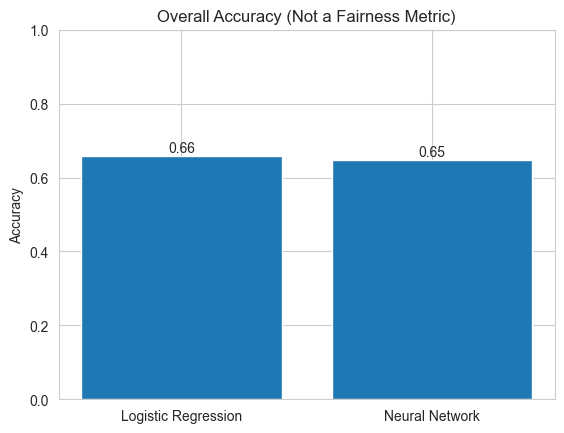

In [57]:


models = ["Logistic Regression", "Neural Network"]
accs = [lr_results["accuracy"], nn_results["accuracy"]]

plt.bar(models, accs)
plt.ylabel("Accuracy")
plt.title("Overall Accuracy (Not a Fairness Metric)")
plt.ylim(0, 1)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.show()


In [58]:


def plot_lr_nn_rates(lr_rates, nn_rates, group_col, title):
    """
    lr_rates, nn_rates: DataFrames from compute_group_rates
    group_col: "race" or "gender"
    """

    metrics = ["TPR", "FNR", "FPR", "TNR"]
    groups = lr_rates[group_col].values

    x = np.arange(len(groups))
    width = 0.35

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4), sharey=False)
    fig.suptitle(title, fontsize=14)

    for i, metric in enumerate(metrics):
        ax = axes[i]

        lr_vals = lr_rates[metric].values
        nn_vals = nn_rates[metric].values

        bars_lr = ax.bar(x - width/2, lr_vals, width, label="LR")
        bars_nn = ax.bar(x + width/2, nn_vals, width, label="NN")

        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(groups)
        ax.set_ylim(0, 1)

        # annotate bars
        for bar in bars_lr:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=9)

        for bar in bars_nn:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=9)

        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()


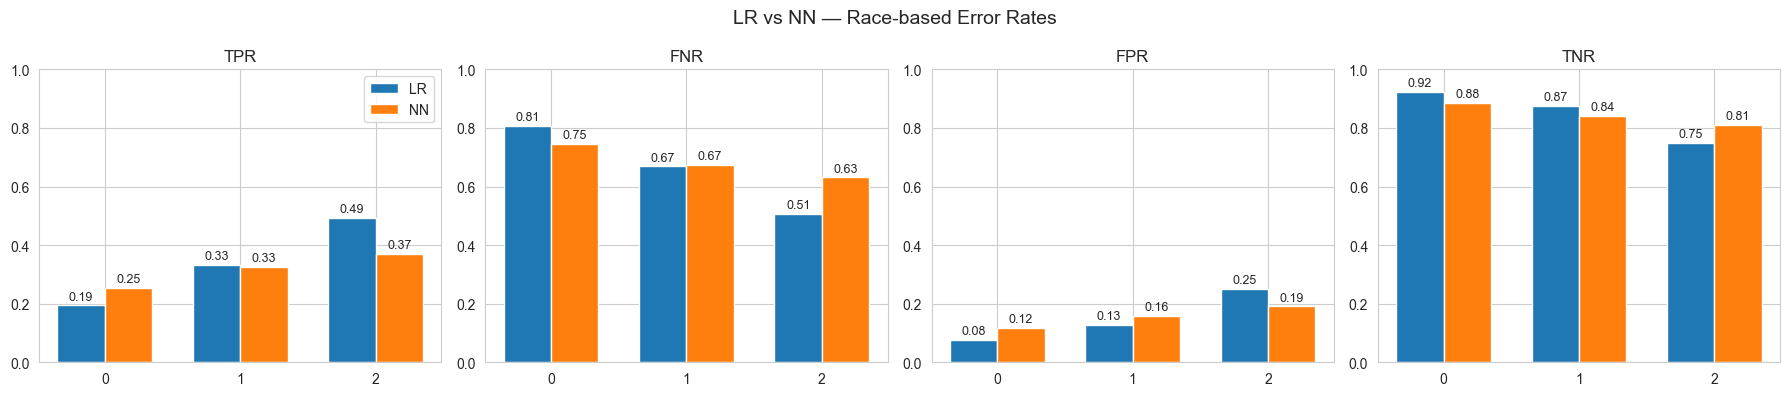

In [59]:
plot_lr_nn_rates(
    lr_rates_race,
    nn_rates_race,
    group_col="race",
    title="LR vs NN — Race-based Error Rates"
)


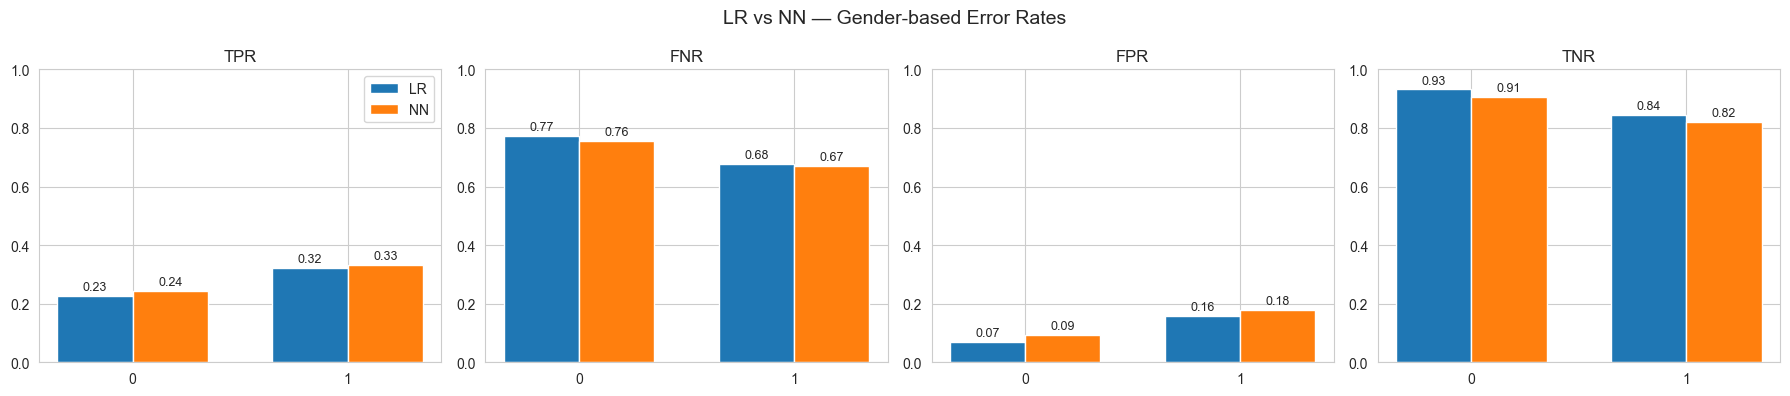

In [60]:
plot_lr_nn_rates(
    lr_rates_gender,
    nn_rates_gender,
    group_col="gender",
    title="LR vs NN — Gender-based Error Rates"
)
